Raw shapes
account: (400, 6)
support: (918, 7)
activity: (445, 3)

Overall KPIs
                metric  value
             customers 400.00
              churners 114.00
overall_churn_rate_pct  28.50
   avg_activity_events   1.11
      avg_ticket_count   2.30
  avg_resolution_hours  10.23
     at_risk_customers 170.00
      at_risk_rate_pct  42.50

Churn by plan
      plan  customers  churners  churn_rate  avg_activity_events  avg_ticket_count  avg_resolution_hours  churn_rate_pct
      Free        105        43    0.409524             0.933333          2.342857             11.707231            41.0
Enterprise         92        24    0.260870             1.260870          2.141304              9.767482            26.1
     Basic        118        28    0.237288             1.220339          2.347458              9.699918            23.7
       Pro         85        19    0.223529             1.023529          2.329412              9.605831            22.4

Churn by activity segment
act

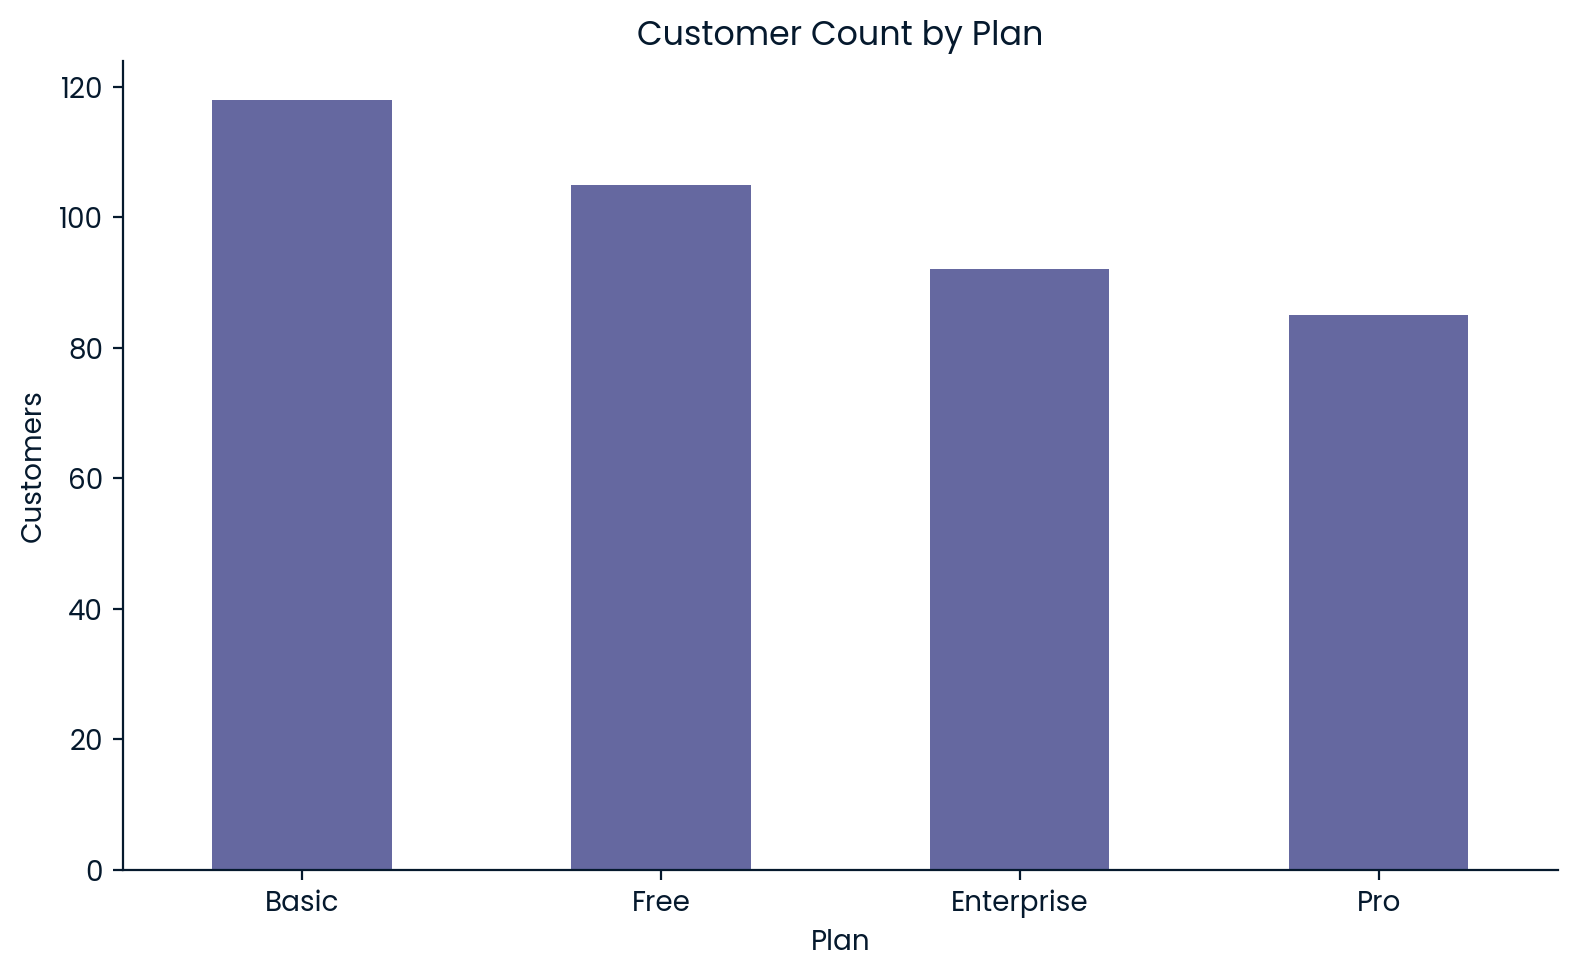

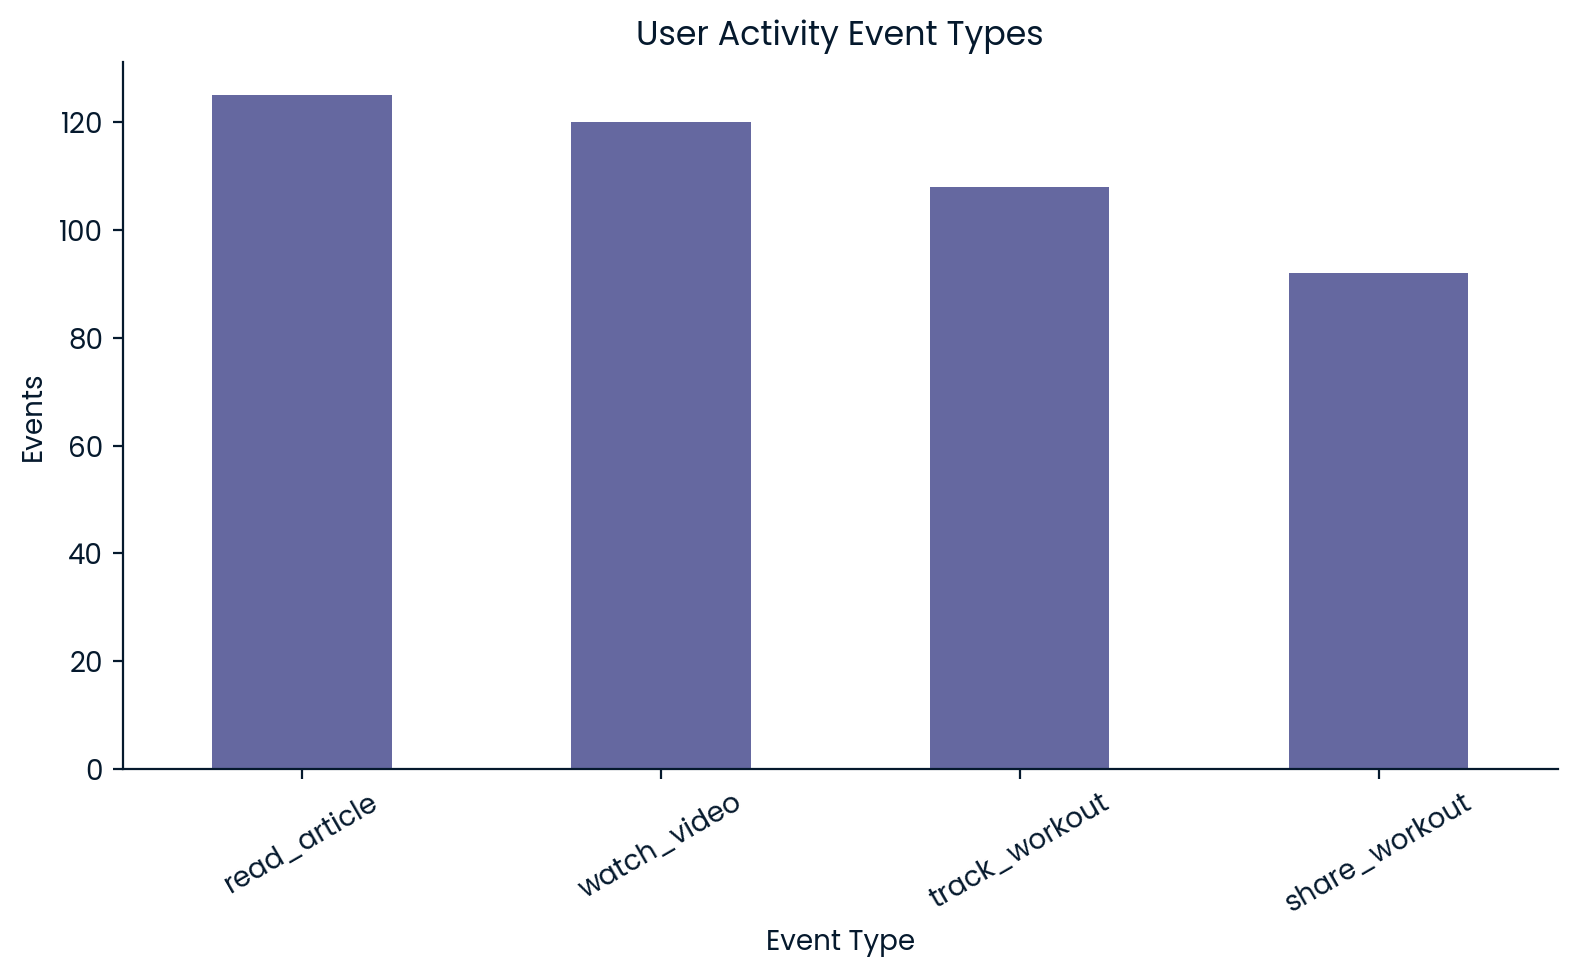

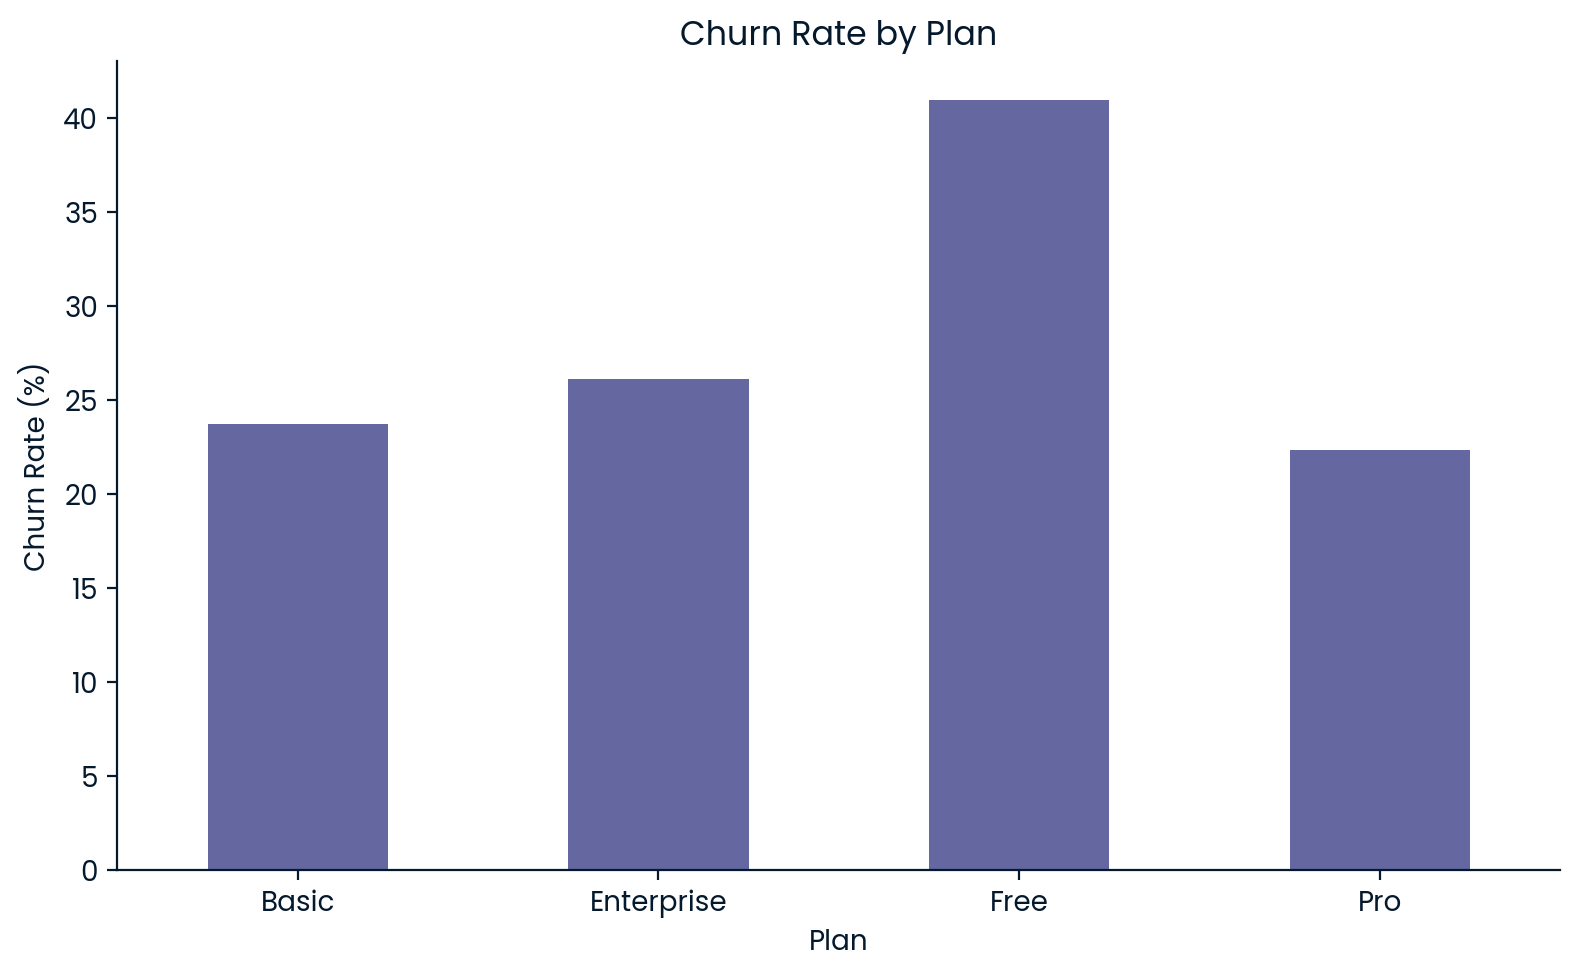

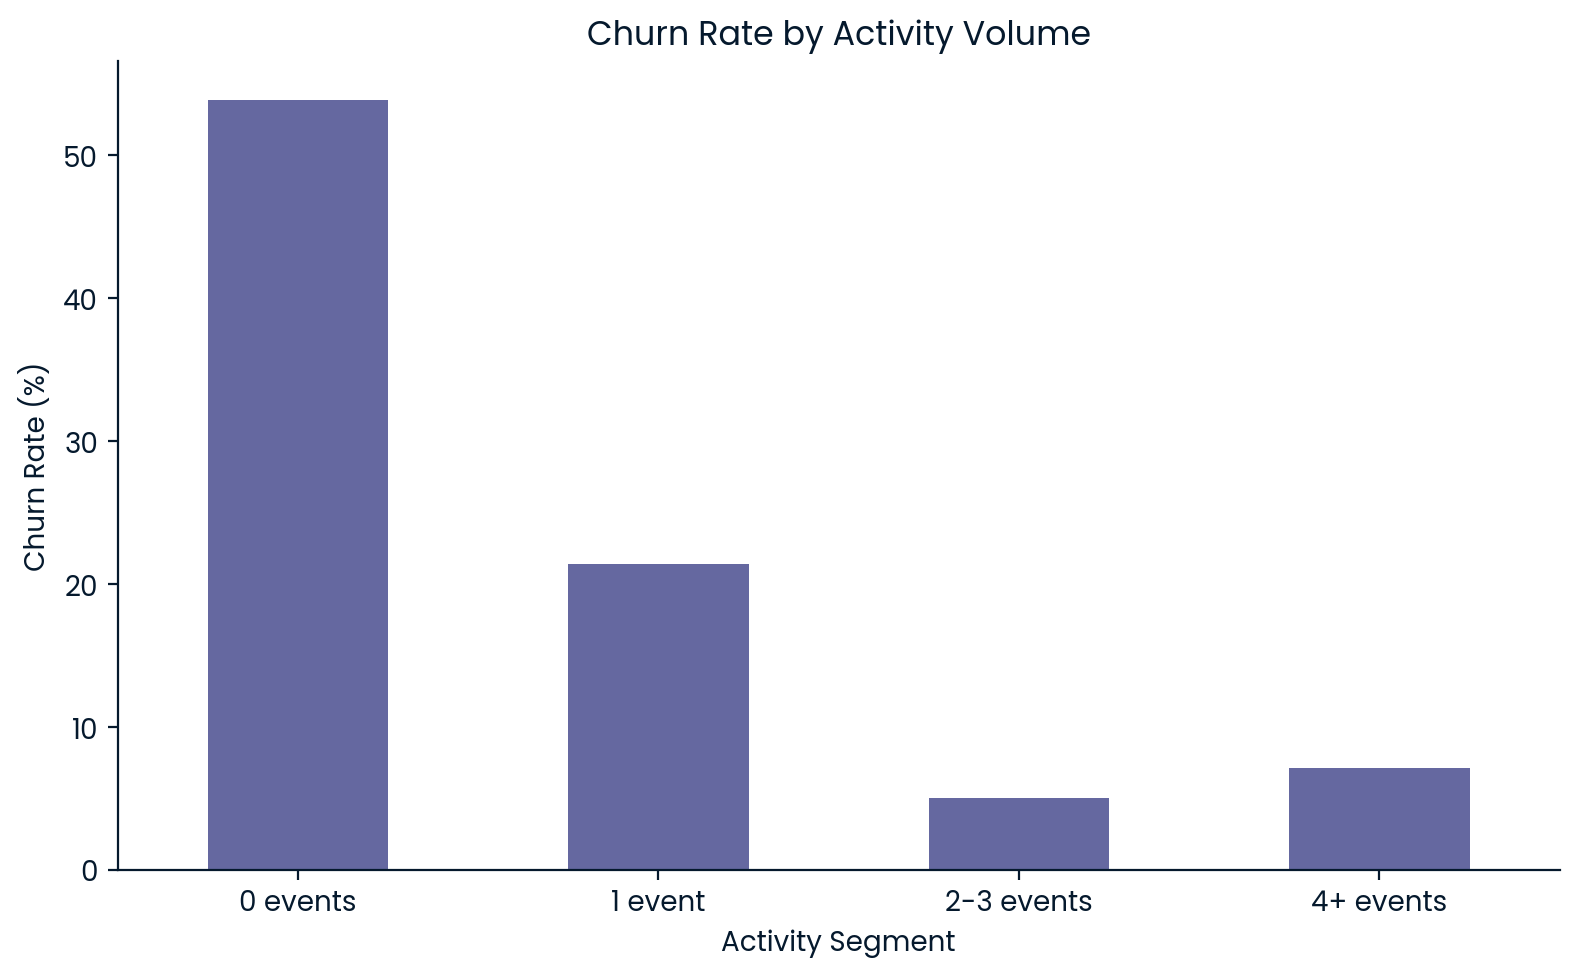

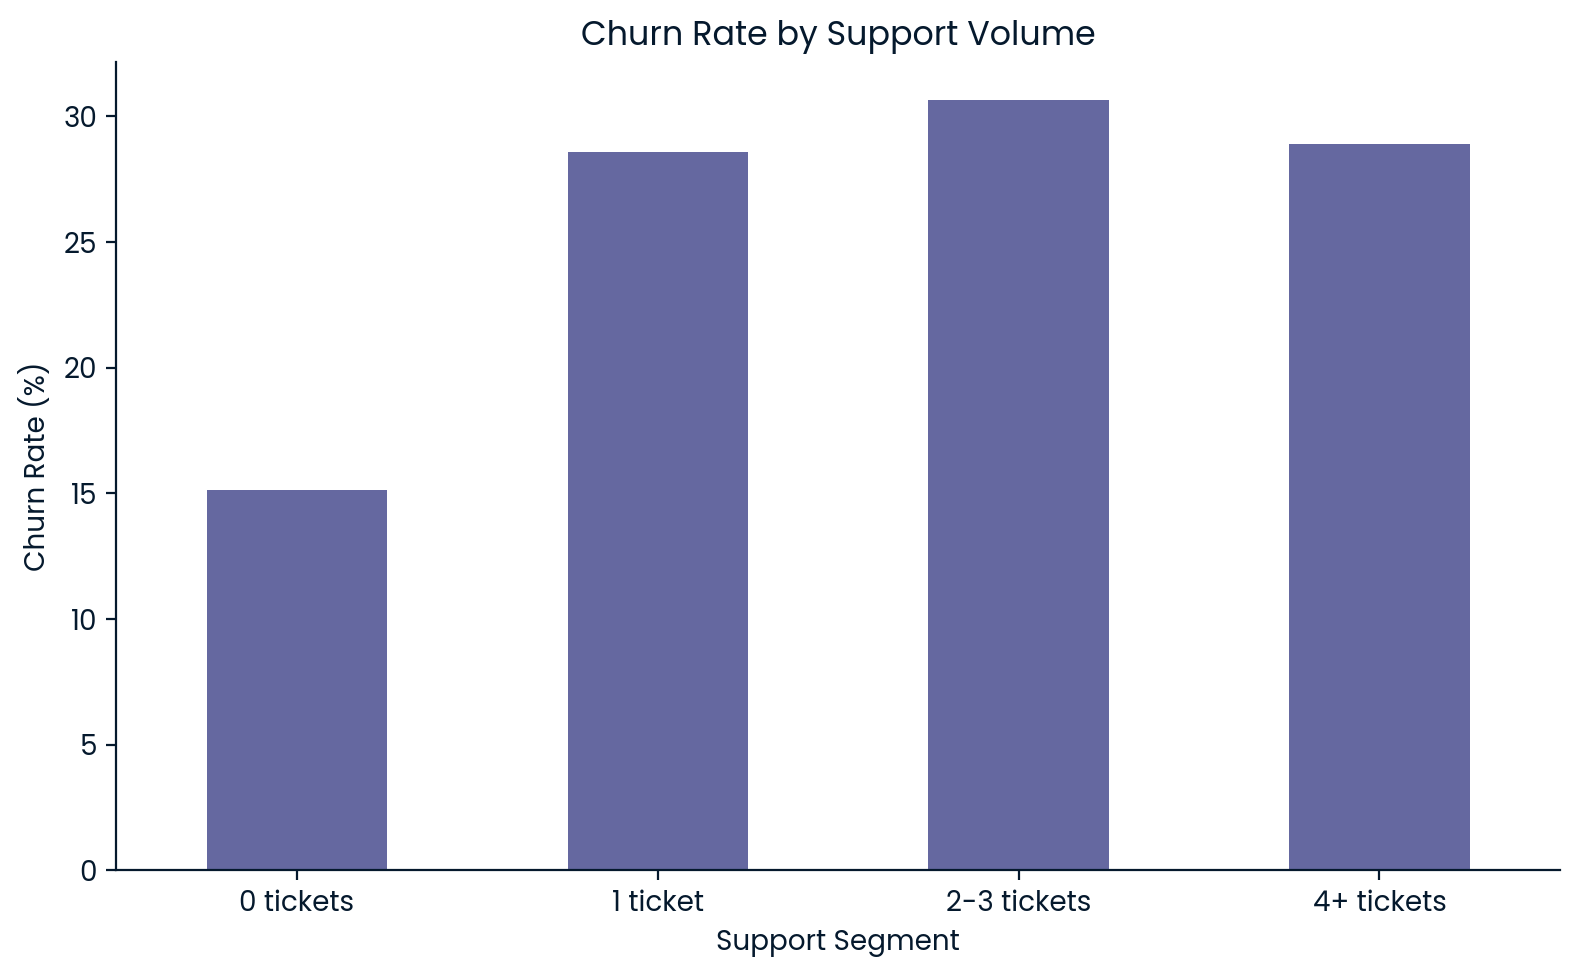

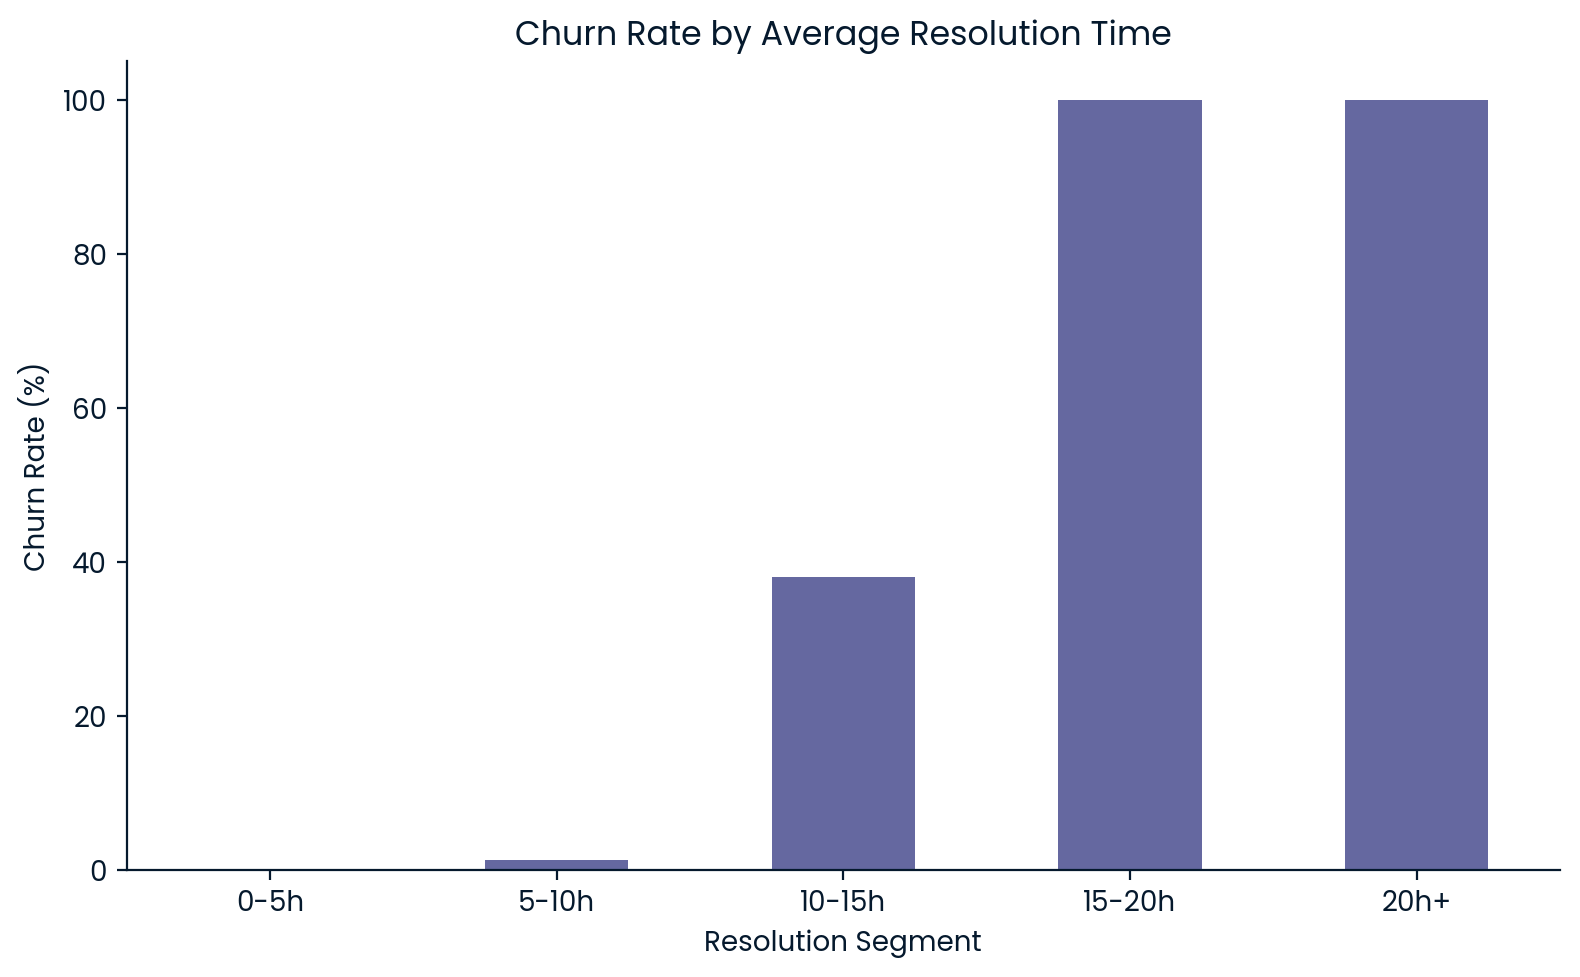

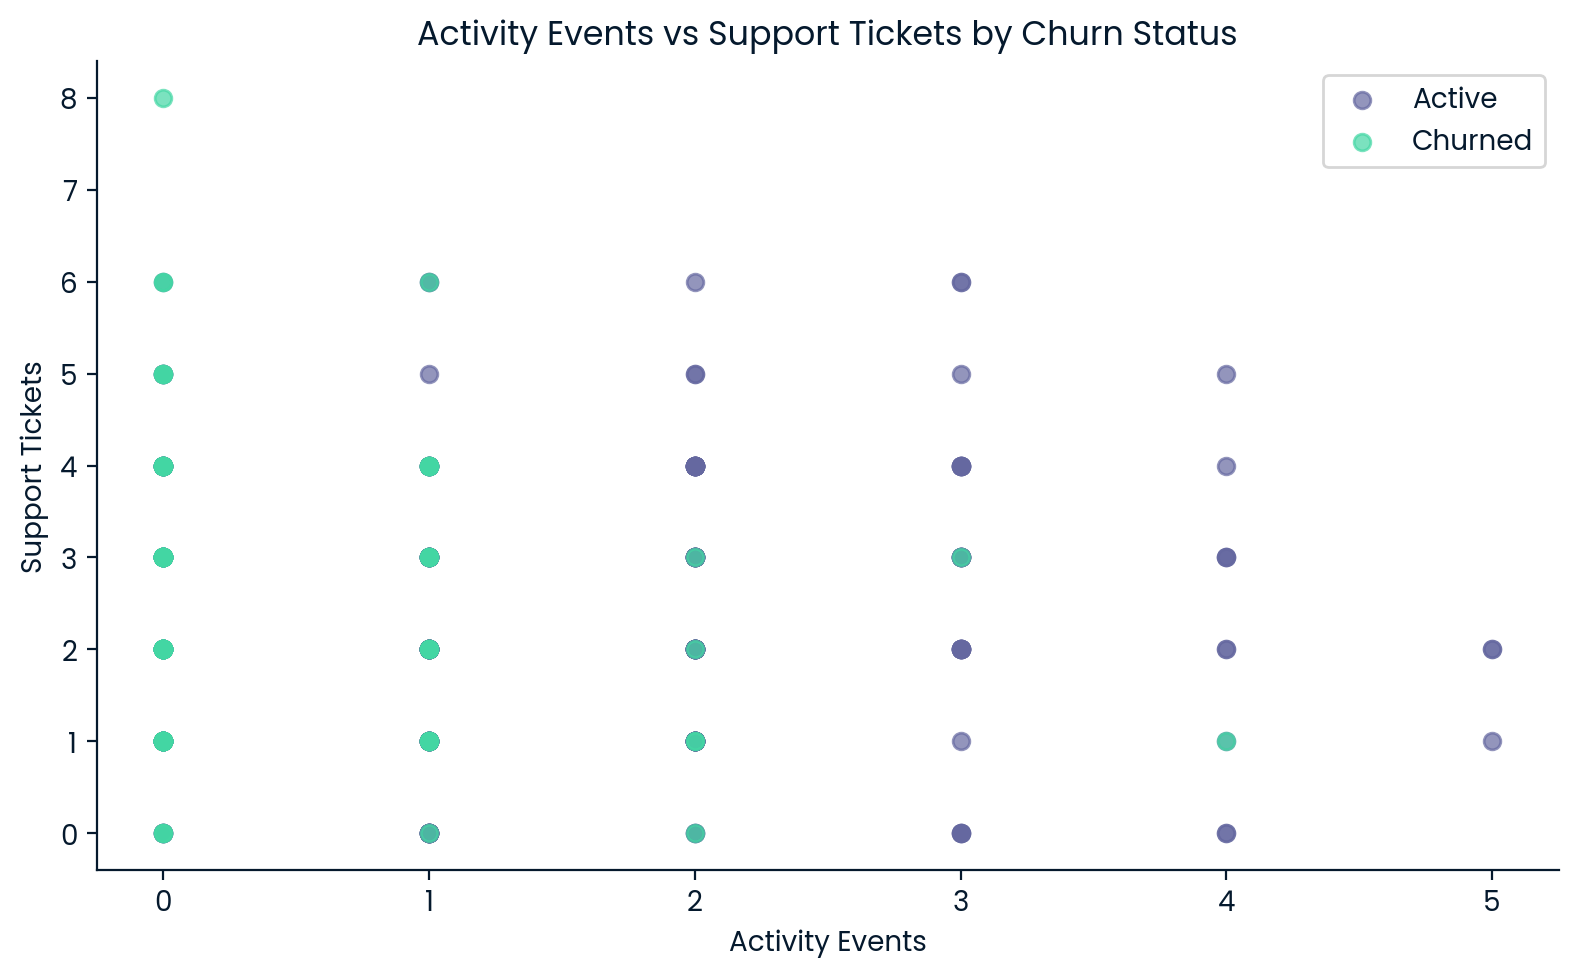


Done. Outputs saved in: /work/files/workspace/fitly_outputs


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0. File loading

DATA_DIR = Path(".")  
OUT_DIR = Path("fitly_outputs")
OUT_DIR.mkdir(exist_ok=True)

ACCOUNT_FILE = DATA_DIR / "da_fitly_account_info.csv"
SUPPORT_FILE = DATA_DIR / "da_fitly_customer_support.csv"
ACTIVITY_FILE = DATA_DIR / "da_fitly_user_activity.csv"

account = pd.read_csv(ACCOUNT_FILE)
support = pd.read_csv(SUPPORT_FILE)
activity = pd.read_csv(ACTIVITY_FILE)

print("Raw shapes")
print("account:", account.shape)
print("support:", support.shape)
print("activity:", activity.shape)

# 1. Validation checks

def validation_summary(df, name):
    return pd.DataFrame({
        "dataset": name,
        "column": df.columns,
        "dtype_before": [str(df[c].dtype) for c in df.columns],
        "missing_values": [df[c].isna().sum() for c in df.columns],
        "unique_values": [df[c].nunique(dropna=True) for c in df.columns],
        "sample_values": [df[c].dropna().astype(str).head(3).tolist() for c in df.columns],
    })

validation_before = pd.concat([
    validation_summary(account, "account_info"),
    validation_summary(support, "customer_support"),
    validation_summary(activity, "user_activity"),
], ignore_index=True)
validation_before.to_csv(OUT_DIR / "validation_before_cleaning.csv", index=False)

# 2. Cleaning

# Account data
account = account.rename(columns={"churn_status": "churn"})
account["customer_id"] = account["customer_id"].astype(str).str.strip().str.upper()
account["email"] = account["email"].astype(str).str.strip().str.lower()
account["state"] = account["state"].astype(str).str.strip().str.title()
account["plan"] = account["plan"].astype(str).str.strip().str.title()
account["plan_list_price"] = pd.to_numeric(account["plan_list_price"], errors="coerce")
account["churn"] = account["churn"].astype(str).str.strip().str.upper()
account["churned"] = account["churn"].eq("Y").astype(int)
account["user_id"] = pd.to_numeric(account["customer_id"].str.extract(r"(\d+)")[0], errors="coerce").astype("Int64")

# Support data
support["ticket_time"] = pd.to_datetime(support["ticket_time"], errors="coerce")
support["user_id"] = pd.to_numeric(support["user_id"], errors="coerce").astype("Int64")
support["channel"] = support["channel"].astype(str).str.strip().str.lower().replace({"nan": np.nan, "": np.nan})
support["topic"] = support["topic"].astype(str).str.strip().str.lower().replace({"nan": np.nan, "": np.nan})
support["resolution_time_hours"] = pd.to_numeric(support["resolution_time_hours"], errors="coerce")
support["ticket_state"] = pd.to_numeric(support["state"], errors="coerce").astype("Int64")

if "comments" in support.columns:
    support["deletion_request"] = support["comments"].fillna("").str.contains(
        r"delete|erase|erasure|remove|forgotten|wipe", case=False, regex=True
    ).astype(int)
else:
    support["deletion_request"] = 0

# User activity data
activity["event_time"] = pd.to_datetime(activity["event_time"], errors="coerce")
activity["user_id"] = pd.to_numeric(activity["user_id"], errors="coerce").astype("Int64")
activity["event_type"] = activity["event_type"].astype(str).str.strip().str.lower().replace({"nan": np.nan, "": np.nan})

# Remove unusable records after validation/cleaning
account = account.dropna(subset=["user_id"])
support = support.dropna(subset=["user_id", "ticket_time"])
activity = activity.dropna(subset=["user_id", "event_time"])

validation_after = pd.concat([
    validation_summary(account, "account_info_clean"),
    validation_summary(support, "customer_support_clean"),
    validation_summary(activity, "user_activity_clean"),
], ignore_index=True)
validation_after.to_csv(OUT_DIR / "validation_after_cleaning.csv", index=False)

# 3. Feature engineering

as_of_date = max(activity["event_time"].max(), support["ticket_time"].max())

activity_agg = activity.groupby("user_id").agg(
    activity_events=("event_type", "size"),
    active_days=("event_time", lambda s: s.dt.date.nunique()),
    last_event_time=("event_time", "max")
).reset_index()
activity_agg["days_since_last_activity"] = (as_of_date - activity_agg["last_event_time"]).dt.days

activity_type_counts = pd.crosstab(activity["user_id"], activity["event_type"]).add_prefix("activity_").reset_index()
activity_agg = activity_agg.merge(activity_type_counts, on="user_id", how="left")

support_agg = support.groupby("user_id").agg(
    ticket_count=("topic", "size"),
    avg_resolution_hours=("resolution_time_hours", "mean"),
    max_resolution_hours=("resolution_time_hours", "max"),
    deletion_requests=("deletion_request", "sum"),
    unresolved_tickets=("ticket_state", lambda s: (s == 0).sum()),
    resolved_tickets=("ticket_state", lambda s: (s == 1).sum())
).reset_index()

support_topic_counts = pd.crosstab(support["user_id"], support["topic"]).add_prefix("ticket_topic_").reset_index()
support_channel_counts = pd.crosstab(support["user_id"], support["channel"]).add_prefix("ticket_channel_").reset_index()
support_agg = support_agg.merge(support_topic_counts, on="user_id", how="left")
support_agg = support_agg.merge(support_channel_counts, on="user_id", how="left")

user = account.merge(activity_agg, on="user_id", how="left").merge(support_agg, on="user_id", how="left")

# Fill count fields with zero where a user had no activity/support records
count_cols = [c for c in user.columns if c.startswith("activity_") or c.startswith("ticket_")]
count_cols += ["activity_events", "active_days", "ticket_count", "deletion_requests", "unresolved_tickets", "resolved_tickets"]
for col in count_cols:
    if col in user.columns:
        user[col] = user[col].fillna(0)

user["activity_segment"] = pd.cut(
    user["activity_events"],
    bins=[-1, 0, 1, 3, np.inf],
    labels=["0 events", "1 event", "2-3 events", "4+ events"]
)
user["support_segment"] = pd.cut(
    user["ticket_count"],
    bins=[-1, 0, 1, 3, np.inf],
    labels=["0 tickets", "1 ticket", "2-3 tickets", "4+ tickets"]
)
user["resolution_segment"] = pd.cut(
    user["avg_resolution_hours"],
    bins=[0, 5, 10, 15, 20, np.inf],
    labels=["0-5h", "5-10h", "10-15h", "15-20h", "20h+"],
    include_lowest=True
)

# KPI recommendation: at-risk users with poor support experience or no activity despite support contact
user["high_resolution_risk"] = (user["avg_resolution_hours"] > 15).fillna(False)
user["inactive_support_risk"] = ((user["activity_events"] == 0) & (user["ticket_count"] > 0))
user["at_risk"] = user["high_resolution_risk"] | user["inactive_support_risk"]

user.to_csv(OUT_DIR / "customer_level_churn_dataset.csv", index=False)

# 4. KPI tables

def churn_table(df, group_col):
    out = df.groupby(group_col, observed=False).agg(
        customers=("user_id", "count"),
        churners=("churned", "sum"),
        churn_rate=("churned", "mean"),
        avg_activity_events=("activity_events", "mean"),
        avg_ticket_count=("ticket_count", "mean"),
        avg_resolution_hours=("avg_resolution_hours", "mean")
    ).reset_index()
    out["churn_rate_pct"] = (out["churn_rate"] * 100).round(1)
    return out

overall_kpis = pd.DataFrame({
    "metric": [
        "customers", "churners", "overall_churn_rate_pct", "avg_activity_events",
        "avg_ticket_count", "avg_resolution_hours", "at_risk_customers", "at_risk_rate_pct"
    ],
    "value": [
        len(user), user["churned"].sum(), round(user["churned"].mean() * 100, 1),
        round(user["activity_events"].mean(), 2), round(user["ticket_count"].mean(), 2),
        round(user["avg_resolution_hours"].mean(), 2), int(user["at_risk"].sum()),
        round(user["at_risk"].mean() * 100, 1)
    ]
})

tables = {
    "overall_kpis": overall_kpis,
    "churn_by_plan": churn_table(user, "plan"),
    "churn_by_activity_segment": churn_table(user, "activity_segment"),
    "churn_by_support_segment": churn_table(user, "support_segment"),
    "churn_by_resolution_segment": churn_table(user.dropna(subset=["resolution_segment"]), "resolution_segment"),
    "churn_by_at_risk": churn_table(user, "at_risk"),
}

with pd.ExcelWriter(OUT_DIR / "fitly_churn_summary_tables.xlsx") as writer:
    for sheet, df in tables.items():
        df.to_excel(writer, sheet_name=sheet[:31], index=False)

print("\nOverall KPIs")
print(overall_kpis.to_string(index=False))
print("\nChurn by plan")
print(tables["churn_by_plan"].sort_values("churn_rate", ascending=False).to_string(index=False))
print("\nChurn by activity segment")
print(tables["churn_by_activity_segment"].to_string(index=False))
print("\nChurn by support segment")
print(tables["churn_by_support_segment"].to_string(index=False))
print("\nChurn by resolution segment")
print(tables["churn_by_resolution_segment"].to_string(index=False))
print("\nChurn by at-risk KPI")
print(tables["churn_by_at_risk"].to_string(index=False))

# 5. Graphics required by brief

def save_bar(series, title, xlabel, ylabel, filename, rotation=0):
    ax = series.plot(kind="bar", figsize=(8, 5), rot=rotation)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=200)
    plt.show()

# Single-variable graphic 1: plan distribution
save_bar(
    account["plan"].value_counts(),
    "Customer Count by Plan",
    "Plan",
    "Customers",
    "01_customer_count_by_plan.png"
)

# Single-variable graphic 2: activity event distribution
save_bar(
    activity["event_type"].value_counts(),
    "User Activity Event Types",
    "Event Type",
    "Events",
    "02_activity_event_types.png",
    rotation=30
)

# Two-or-more-variable graphics: churn by plan, activity, support, and resolution time
save_bar(
    tables["churn_by_plan"].set_index("plan")["churn_rate"] * 100,
    "Churn Rate by Plan",
    "Plan",
    "Churn Rate (%)",
    "03_churn_rate_by_plan.png"
)

save_bar(
    tables["churn_by_activity_segment"].set_index("activity_segment")["churn_rate"] * 100,
    "Churn Rate by Activity Volume",
    "Activity Segment",
    "Churn Rate (%)",
    "04_churn_rate_by_activity.png"
)

save_bar(
    tables["churn_by_support_segment"].set_index("support_segment")["churn_rate"] * 100,
    "Churn Rate by Support Volume",
    "Support Segment",
    "Churn Rate (%)",
    "05_churn_rate_by_support.png"
)

save_bar(
    tables["churn_by_resolution_segment"].set_index("resolution_segment")["churn_rate"] * 100,
    "Churn Rate by Average Resolution Time",
    "Resolution Segment",
    "Churn Rate (%)",
    "06_churn_rate_by_resolution_time.png"
)

# Extra plot: activity vs support, colored by churn status
fig, ax = plt.subplots(figsize=(8, 5))
for churn_value, label in [(0, "Active"), (1, "Churned")]:
    subset = user[user["churned"] == churn_value]
    ax.scatter(subset["activity_events"], subset["ticket_count"], alpha=0.7, label=label)
ax.set_title("Activity Events vs Support Tickets by Churn Status")
ax.set_xlabel("Activity Events")
ax.set_ylabel("Support Tickets")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "07_activity_vs_support_by_churn.png", dpi=200)
plt.show()

print(f"\nDone. Outputs saved in: {OUT_DIR.resolve()}")
